# Car Data Analysis using Python

**Student:** Parmanand Singh

This project analyzes the CarDekho dataset by solving 25 analytical tasks using Python and its data analysis libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

data = pd.read_csv('car_data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Q.1 From which manufacturing year to which manufacturing year vehicles are present in this data ?

**Answer:** Vehicles are present from **2003** to **2018**.

In [2]:
data['Year'].agg(['min','max'])

min    2003
max    2018
Name: Year, dtype: int64

### Q.2 What is the lowest price to which a vehicle is sold ?

**Answer:** 0.1 lakh

In [3]:
data['Selling_Price'].min()

np.float64(0.1)

### Q.3 What is the highest price to which a vehicle is sold ?

**Answer:** 35.0 lakh

In [4]:
data['Selling_Price'].max()

np.float64(35.0)

### Q.4 How many records are there in this data ?

**Answer:** 301

In [5]:
len(data)

301

### Q.5 Are there any missing records in this data ?

**Answer:** 0 missing values

In [6]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### Q.6 How many different vehicles are present in this data ?

**Answer:** 98 unique vehicles

In [7]:
data['Car_Name'].nunique()

98

### Q.7 Which is the most sold vehicle in this data ?

**Answer:** city (26 records)

In [8]:
data['Car_Name'].value_counts().head(1)

Car_Name
city    26
Name: count, dtype: int64

### Q.8 Does the database include any CNG vehicle ? if yes how many of them are there ?

**Answer:** 2

In [9]:
(data['Fuel_Type']=='CNG').sum()

np.int64(2)

### Q.9 How many vehicles here are for sell from individuals directly ?

**Answer:** 106

In [10]:
(data['Seller_Type']=='Individual').sum()

np.int64(106)

### Q.10 Does the databse contain auto tranmission vehicles ? if yes how many of them are there ?

**Answer:** 40

In [11]:
(data['Transmission']=='Automatic').sum()

np.int64(40)

### Q.11 How many single person owned vehicles are there in the database ?

**Answer:** 10

In [12]:
(data['Owner']==1).sum()

np.int64(10)

### Q.12 Which is the most and least cost depreciated vehicle in data ?

**Most:** land cruiser (57.60)

**Least:** Honda Activa 4G (0.03)

In [13]:
data['Depreciation']=data['Present_Price']-data['Selling_Price']
most=data.loc[data['Depreciation'].idxmax(),['Car_Name','Depreciation']]
least=data.loc[data['Depreciation'].idxmin(),['Car_Name','Depreciation']]
pd.DataFrame([most,least],index=['Most','Least'])

,Car_Name,Depreciation
Most,land cruiser,57.60
Least,Honda Activa 4G,0.03


### Q.13 Which brands of vehicles are less affected bycost depreciation ?

Top 10 brands with lowest average depreciation.

In [14]:
def brand(x):
    if x.startswith('Royal Enfield'): return 'Royal Enfield'
    if x.startswith('Hero Honda'): return 'Hero Honda'
    if x.startswith('UM '): return 'UM'
    return x.split()[0]
data['Brand']=data['Car_Name'].apply(brand)
brand_dep=data.groupby('Brand')['Depreciation'].mean().sort_values()
brand_dep.head(10)

Brand
UM            0.120000
Activa        0.183333
TVS           0.242750
Mahindra      0.250000
Hero          0.258538
Yamaha        0.258750
Hero Honda    0.308500
Honda         0.318824
Suzuki        0.330000
Bajaj         0.334400
Name: Depreciation, dtype: float64

### Q.14 Are there any factors which you feel affect the cost depreciation ? 

Age, kilometers driven, brand value, fuel type and transmission are the major factors observed.

In [15]:
# Observation based question
print('Answer written in markdown.')

Answer written in markdown.


### Q.15 In general selling price is affected by age of vehicle and distance driven by vehicle, is it observable from data ? 

Older vehicles and higher driven kilometers generally have lower selling prices.

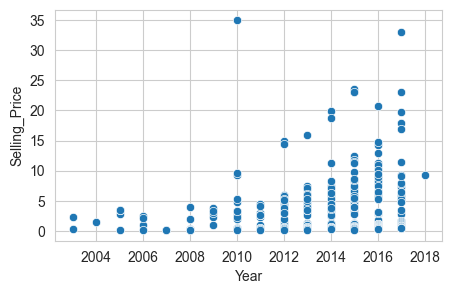

In [16]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=data,x='Year',y='Selling_Price')
plt.show()

### Q.16 Can we get idea about newest vehicle i.e. after 2014 manufactured ?

**Answer:** 185 records

In [17]:
data[data['Year']>=2014][['Car_Name','Year']].sort_values('Year',ascending=False)

,Car_Name,Year
5,vitara brezza,2018
10,alto 800,2017
2,ciaz,2017
21,ignis,2017
27,swift,2017
...,...,...
274,brio,2014
279,city,2014
282,city,2014
290,amaze,2014


### Q.17 Can we find out data of only two wheelers from this data ? 

**Assumption:** The dataset has no Vehicle_Type column. Two-wheelers are identified using model names.

In [18]:
bike_keywords=['Activa','Pulsar','Apache','FZ','Splender','Passion','Classic','Bullet','CBR','Karizma','Avenger','Discover','Dominar','Duke','RC','Access','Jupiter','Wego']
pattern='|'.join(bike_keywords)
two_wheeler=data[data['Car_Name'].str.contains(pattern,case=False,na=False)]
two_wheeler[['Car_Name','Year','Selling_Price']].head()

,Car_Name,Year,Selling_Price
102,KTM RC200,2017,1.65
103,Bajaj Dominar 400,2017,1.45
104,Royal Enfield Classic 350,2017,1.35
105,KTM RC390,2015,1.35
109,Royal Enfield Classic 350,2017,1.20


### Q.18 Which is the oldest bike sold here ?

**Answer:** Bajaj Pulsar 150 (2006)

In [19]:
two_wheeler.sort_values('Year')[['Car_Name','Year']].head(1)

,Car_Name,Year
200,Bajaj Pulsar 150,2006


### Q.19 Which is the newest bike sold here ?

**Answer:** KTM RC200 (2017)

In [20]:
two_wheeler.sort_values('Year',ascending=False)[['Car_Name','Year']].head(1)

,Car_Name,Year
102,KTM RC200,2017


### Q.20 Which is the most sold bike here ?

**Answer:** Royal Enfield Classic 350 (7)

In [21]:
two_wheeler['Car_Name'].value_counts().head(1)

Car_Name
Royal Enfield Classic 350    7
Name: count, dtype: int64

### Q.21 Do you find any deal in two wheelers which exceeded the general exception ? Can you find reason for it ?

Royal Enfield and KTM models retain higher resale value due to strong brand demand.

In [22]:
two_wheeler.sort_values('Depreciation').head(5)[['Car_Name','Selling_Price','Present_Price','Depreciation']]

,Car_Name,Selling_Price,Present_Price,Depreciation
155,Honda Activa 4G,0.48,0.51,0.03
126,Bajaj Avenger 220,0.90,0.95,0.05
151,Hero Passion X pro,0.50,0.55,0.05
127,Bajaj Avenger 150,0.75,0.80,0.05
129,Yamaha FZ S V 2.0,0.78,0.84,0.06


### Q.22 Can we find out data of only cars from this data ?

**Answer:** 202 car records

In [23]:
car_data=data.drop(two_wheeler.index)
car_data[['Car_Name','Year']].head()

,Car_Name,Year
0,ritz,2014
1,sx4,2013
2,ciaz,2017
3,wagon r,2011
4,swift,2014


### Q.23 Which is the oldest car sold here ?

**Answer:** 800 (2003)

In [24]:
car_data.sort_values('Year')[['Car_Name','Year']].head(1)

,Car_Name,Year
37,800,2003


### Q.24 Which is the newest car sold here ?

**Answer:** vitara brezza (2018)

In [25]:
car_data.sort_values('Year',ascending=False)[['Car_Name','Year']].head(1)

,Car_Name,Year
5,vitara brezza,2018


### Q.25 Do you find any deal in cars which exceeded the general exception ? Can you find reason for it ?

Luxury brands show higher depreciation while Toyota models retain value relatively well.

In [26]:
car_data.sort_values('Depreciation',ascending=False).head(5)[['Car_Name','Selling_Price','Present_Price','Depreciation']]

,Car_Name,Selling_Price,Present_Price,Depreciation
86,land cruiser,35.00,92.60,57.60
85,camry,2.50,23.73,21.23
94,corolla altis,4.00,22.78,18.78
78,corolla altis,5.25,22.83,17.58
62,fortuner,18.75,35.96,17.21
